## Clustering 

Clustering is an unsupervised machine learning technique that groups similar data points based on their features.
It helps discover hidden patterns or structures in data without using labeled outputs.

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn scipy

  Using cached pandas-2.3.3-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.4.1-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.17.0-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp313-cp313-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl.metadata (6.4 kB)
  Using cached pillow-12.1.0-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.1-py3-none-any.whl.metadata (5.6 kB)
  Usin

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.spatial import Voronoi, voronoi_plot_2d

In [2]:
dataset=pd.read_csv("credit.csv")

In [27]:
dataset.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
dataset.drop(columns=["CUST_ID"],inplace=True)

In [29]:
dataset.head()


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [11]:
dataset.shape

(8950, 18)

### Checking Null Values

In [30]:
# Check missing values count per column
print(dataset.isnull().sum())

BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64


#### Filling Null or Missing Values with Mean 

In [4]:
dataset["MINIMUM_PAYMENTS"] = dataset["MINIMUM_PAYMENTS"].fillna(dataset["MINIMUM_PAYMENTS"].mean())
dataset["CREDIT_LIMIT"] = dataset["CREDIT_LIMIT"].fillna(dataset["CREDIT_LIMIT"].mean())

In [32]:
# Check missing values count per column
print(dataset.isnull().sum())


BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64


In [38]:
dataset.columns

Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
       'TENURE', 'Cluster'],
      dtype='object')

### Training for 3 Clusters 

In [5]:
kmeans = KMeans(n_clusters=3, random_state=42)
y_kmeans = kmeans.fit_predict(dataset)

In [34]:
y_kmeans

array([1, 0, 0, ..., 1, 1, 1], shape=(8950,), dtype=int32)

In [6]:
# Step 3: Add cluster labels to data
dataset['Cluster'] = y_kmeans

In [36]:
dataset['Cluster'] 

0       1
1       0
2       0
3       0
4       1
       ..
8945    1
8946    1
8947    1
8948    1
8949    1
Name: Cluster, Length: 8950, dtype: int32

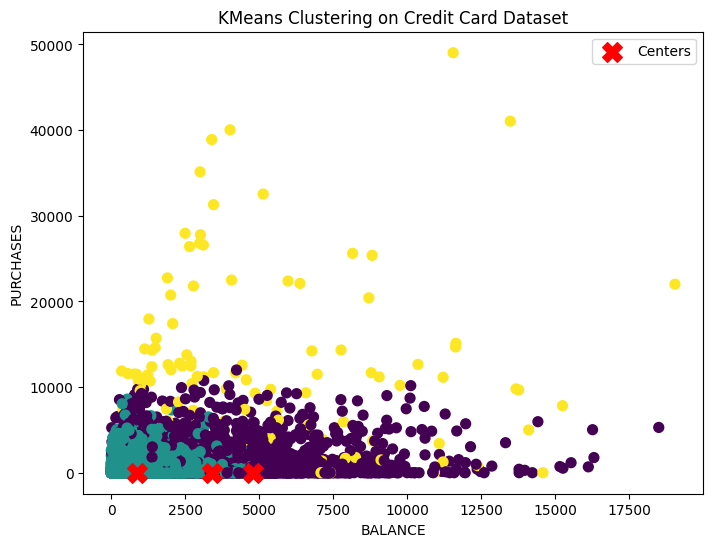

In [24]:

# Step 4: Visualize clusters using 2D (first two features)
plt.figure(figsize=(8,6))
plt.scatter(dataset.iloc[:,0], dataset.iloc[:,2], c=dataset['Cluster'], cmap='viridis', s=50)

# Plot cluster centers
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', label="Centers")

plt.xlabel(dataset.columns[0])
plt.ylabel(dataset.columns[2])
plt.title("KMeans Clustering on Credit Card Dataset")
plt.legend()
plt.show()

#### Taking Prediction on one Sample

In [39]:
# Taking Prediction on one sample, belongs to which cluster
# 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
    #    'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
    #    'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
    #    'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
    #    'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
    #    'TENURE'
sample = [[2000, 0.8, 1500, 200, 300, 100, 0.5, 0.1, 0.3, 0.2, 2, 15, 5000, 1000, 150, 0.1, 12]]
predicted_cluster = kmeans.predict(sample)
print(f"The sample belongs to cluster: {predicted_cluster[0]}")
            

The sample belongs to cluster: 1


c:\Users\786\Desktop\Sessions\MachineLearning---DeepLearning\06-a-Credit-Card-Clustering\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [40]:
# Whats the Average Balance of CLuster 0,1,2
cluster1 = dataset[dataset['Cluster'] == 0]
cluster2 = dataset[dataset['Cluster'] == 1]
cluster3 = dataset[dataset['Cluster'] == 2]

print("Average Balance of Cluster 0:", cluster1['BALANCE'].mean())
print("Average Balance of Cluster 1:", cluster2['BALANCE'].mean())
print("Average Balance of Cluster 2:", cluster3['BALANCE'].mean())

Average Balance of Cluster 0: 3395.8739855109075
Average Balance of Cluster 1: 854.6721726106682
Average Balance of Cluster 2: 4797.203573253732


In [41]:
# Whats the Average Credit Limit of CLuster 0,1,2
cluster1 = dataset[dataset['Cluster'] == 0]
cluster2 = dataset[dataset['Cluster'] == 1]
cluster3 = dataset[dataset['Cluster'] == 2]

print("Average Credit Limit of Cluster 0:", cluster1['CREDIT_LIMIT'].mean())
print("Average Credit Limit of Cluster 1:", cluster2['CREDIT_LIMIT'].mean())
print("Average Credit Limit of Cluster 2:", cluster3['CREDIT_LIMIT'].mean())

Average Credit Limit of Cluster 0: 8998.213152467279
Average Credit Limit of Cluster 1: 2748.3703303660886
Average Credit Limit of Cluster 2: 12470.522388059702


## Performance Metrics for Clustering

Like Classification there is no performance metric for clustering, there are seperate metrics 
like silhouette score, davies bouldin score metrics etc 


In [8]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [9]:
# Calculate clustering metrics
silhouette = silhouette_score(dataset, kmeans.labels_)
db_index = davies_bouldin_score(dataset, kmeans.labels_)
ch_index = calinski_harabasz_score(dataset, kmeans.labels_)

# Print the metric scores
print(f"Silhouette Score: {silhouette:.2f}")
print(f"Davies-Bouldin Index: {db_index:.2f}")
print(f"Calinski-Harabasz Index: {ch_index:.2f}")

Silhouette Score: 0.47
Davies-Bouldin Index: 1.20
Calinski-Harabasz Index: 3079.39


Interpretation of Your Clustering Metrics
1. Silhouette Score = 0.47

Range: –1 to +1

0.47 = moderate to good clustering

Points are reasonably well separated, but some overlap exists
👉 Not perfect, not bad — acceptable quality

2. Davies–Bouldin Index = 1.20

Lower is better

Values:

< 1.0 → very good

≈ 1.0–1.5 → acceptable

> 2.0 → poor
👉 1.20 = decent clustering, clusters are fairly compact


3. Calinski–Harabasz Index = 3079.39

Higher is better

Measures between-cluster separation vs within-cluster compactness

Value depends on dataset size, so compare across models
👉 High value = strong cluster structure

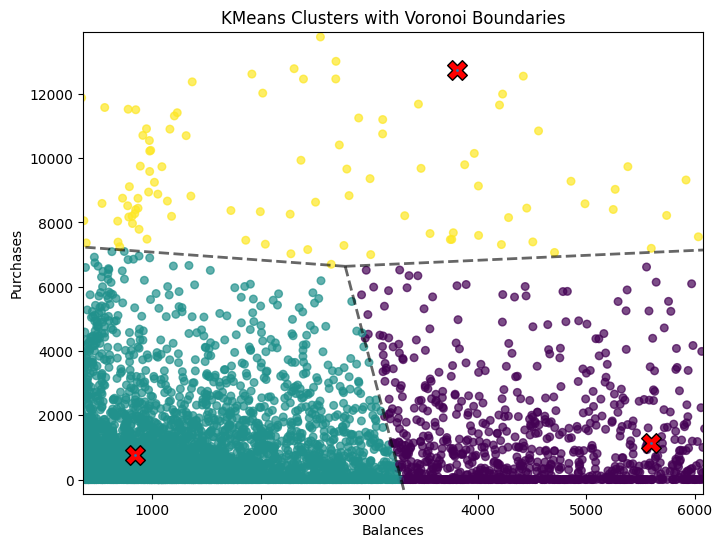

In [64]:
# Take only first 2 columns for visualization
X_2d = dataset[["BALANCE", "PURCHASES"]].values

# Fit KMeans again on 2D data
kmeans = KMeans(n_clusters=3, random_state=42)
y_kmeans = kmeans.fit_predict(X_2d)
centers = kmeans.cluster_centers_

# Plot scatter
plt.figure(figsize=(8,6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_kmeans, cmap="viridis", s=30, alpha=0.7)

# Add Voronoi polygons
vor = Voronoi(centers)
voronoi_plot_2d(vor, ax=plt.gca(), show_vertices=False, line_colors='black', line_width=2, line_alpha=0.6, point_size=2)

# Plot cluster centers
plt.scatter(centers[:, 0], centers[:, 1], c="red", s=200, marker="X", edgecolors="black")

plt.xlabel("Balances")
plt.ylabel("Purchases")
plt.title("KMeans Clusters with Voronoi Boundaries")
plt.show()

### Finding best number of clusters 

The Inertia is the Sum of squared distance of each point From its assigned cluster centroid

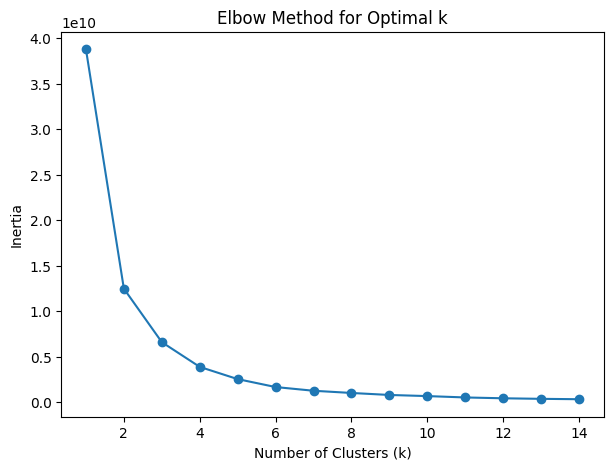

In [44]:
inertia = []
for k in range(1, 15):
    km = KMeans(n_clusters=k, random_state=42).fit(X_2d)
    inertia.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(range(1, 15), inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()


How to interpret Inertia?

Lower inertia → tighter clusters (better fit)

Higher inertia → loose clusters

Inertia always decreases as k increases ❗

⚠️ That’s why inertia alone cannot choose k

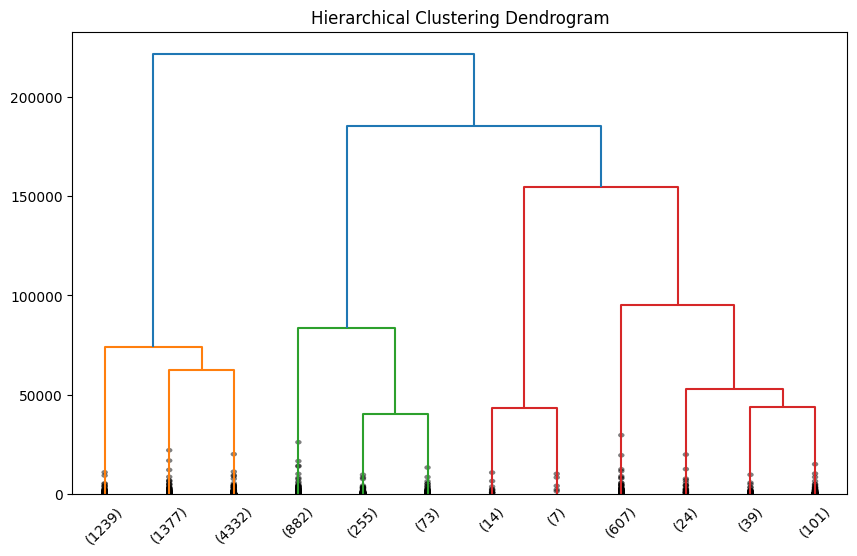

In [56]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(X_2d, 'ward')
plt.figure(figsize=(10, 6))
dendrogram(linked, truncate_mode="lastp", p=12, leaf_rotation=45, leaf_font_size=10, show_contracted=True)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()
